# Data Science Job Market & Salary Trends

## Project Overview

This project evaluates the job market and salary data for careers corresponding to data science and related fields. The scope of this project is to investigate how components such as job title, experience level, employment category, employer location, and remote work may be correlated with differences in salary.

In utilizing Python and Pandas, the dataset will be cleaned, examined, and evaluated to detect patterns within the job market for data-related positions. Visual representations will be generated to develop a better understanding of salary differences and job market patterns across different occupations.

## Key Questions Addressed

- Of all data-related occupations, which job titles appear most frequently?
- Which job positions earn the highest average salaries?
- How do salaries vary when it comes to different experience levels?
- How do salaries differ based on remote work?
- How have salaries changed over time for data-related positions?
- What overall patterns can be observed in the data job market?

## 2. Data Import and Initial Exploration

In this section, the dataset is loaded and assessed to fully grasp its structure, elements and overall effectiveness before performing further evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("ds_salaries.csv")

df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [3]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (3755, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           3755 non-null   int64 
 1   experience_level    3755 non-null   object
 2   employment_type     3755 non-null   object
 3   job_title           3755 non-null   object
 4   salary              3755 non-null   int64 
 5   salary_currency     3755 non-null   object
 6   salary_in_usd       3755 non-null   int64 
 7   employee_residence  3755 non-null   object
 8   remote_ratio        3755 non-null   int64 
 9   company_location    3755 non-null   object
 10  company_size        3755 non-null   object
dtypes: int64(4), object(7)
memory usage: 322.8+ KB


In [4]:
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,3755.000000,3.755000e+03,3755.000000,3755.000000
mean,2022.373635,1.906956e+05,137570.389880,46.271638
std,0.691448,6.716765e+05,63055.625278,48.589050
min,2020.000000,6.000000e+03,5132.000000,0.000000
25%,2022.000000,1.000000e+05,95000.000000,0.000000
50%,2022.000000,1.380000e+05,135000.000000,0.000000
75%,2023.000000,1.800000e+05,175000.000000,100.000000
max,2023.000000,3.040000e+07,450000.000000,100.000000


# 3. Data Cleaning and Planning

Before moving forward in carrying out the analysis, the data set will be reviewed for any missing values, duplicate entries, and other data issues. Additionally, the categorical components are also evaluated to develop a better understanding of how the data is being displayed.

In [5]:
df.isnull().sum()

,0
work_year,0
experience_level,0
employment_type,0
job_title,0
salary,0
salary_currency,0
salary_in_usd,0
employee_residence,0
remote_ratio,0
company_location,0


In [6]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 1171


In [7]:
print("Experience Levels:")
print(df["experience_level"].value_counts())

print("\nEmployment Types:")
print(df["employment_type"].value_counts())

print("\nRemote Work:")
print(df["remote_ratio"].value_counts())

print("\nCompany Sizes:")
print(df["company_size"].value_counts())



Experience Levels:
experience_level
SE    2516
MI     805
EN     320
EX     114
Name: count, dtype: int64

Employment Types:
employment_type
FT    3718
PT      17
CT      10
FL      10
Name: count, dtype: int64

Remote Work:
remote_ratio
0      1923
100    1643
50      189
Name: count, dtype: int64

Company Sizes:
company_size
M    3153
L     454
S     148
Name: count, dtype: int64


## Data Quality Insights

The dataset does not consist of any missing values across its initial 11 variables. It contains a total of 1,171 duplicate rows. Yet, since the dataset does not contain an employee identifier, it is difficult to determine whether these rows depict real duplicate records or different observations with the same characteristics. Due to this, the rows were retained to prevent potentially excluding legitimate observations.

The categorical elements are showcased using abbreviated codes. These elements will be generated into category labels to further optimize the readability of the analysis and visual representations.

In [8]:
experience_map = {
    "EN": "Entry-Level",
    "MI": "Middle-Level",
    "SE": "Senior-Level",
    "EX": "Executive-Level"
}

employment_map = {
    "FT": "Full-Time",
    "PT": "Part-Time",
    "CT": "Contract",
    "FL": "Freelance"
}

remote_map = {
    0: "On-site",
    50: "Hybrid",
    100: "Fully Remote"
}

company_size_map = {
    "S": "Small",
    "M": "Medium",
    "L": "Large"
}

df["experience_level_label"] = df["experience_level"].map(experience_map)
df["employment_type_label"] = df["employment_type"].map(employment_map)
df["remote_work_label"] = df["remote_ratio"].map(remote_map)
df["company_size_label"] = df["company_size"].map(company_size_map)

df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,experience_level_label,employment_type_label,remote_work_label,company_size_label
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L,Senior-Level,Full-Time,Fully Remote,Large
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S,Middle-Level,Contract,Fully Remote,Small
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S,Middle-Level,Contract,Fully Remote,Small
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M,Senior-Level,Full-Time,Fully Remote,Medium
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M,Senior-Level,Full-Time,Fully Remote,Medium


## 4. Job Market Analysis

This section explores the distribution of jobs within the dataset to determine which data-related occupations appear most commonly. Gaining further insight into the frequency of different roles offers insight into the distribution of the data job market showcased in the selected dataset.

In [9]:
top_jobs = df["job_title"].value_counts().head(10)

top_jobs

,count
job_title,
Data Engineer,1040
Data Scientist,840
Data Analyst,612
Machine Learning Engineer,289
Analytics Engineer,103
Data Architect,101
Research Scientist,82
Applied Scientist,58
Data Science Manager,58


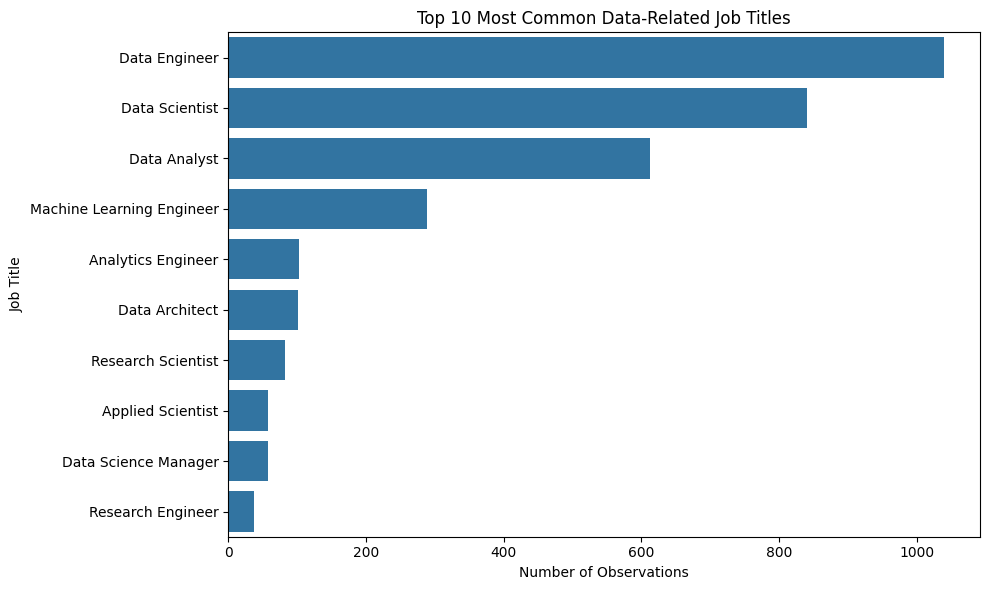

In [10]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_jobs.values,
    y=top_jobs.index
)

plt.title("Top 10 Most Common Data-Related Job Titles")
plt.xlabel("Number of Observations")
plt.ylabel("Job Title")

plt.tight_layout()
plt.show()


## Key Takeaway

Data Engineer was the most common data-related occupation in the dataset we chose, where it holds around 1,040 observations, where Data Scientist comes in second at around 840 observations and Data Analyst comes in third at around 612 observations. Another occupation that was also common was Machine Learning Engineer, sitting at roughly 289 observations.

For the rest of the remaining occupations after these four titles mentioned above, the frequency decreased significantly. This suggests that Data Engineer, Data Scientist, and Data Analyst roles all make up the vast majority of the job observations featured in this particular dataset.

## 5. Salary Analysis

This section investigates salary differences across data-related jobs, levels of experience, and work models. Salaries are compared utilizing the 'salary_in_usd' component to provide a consistent measure across observations recorded in different currencies.

In [11]:
job_salary_stats = (
    df.groupby("job_title")["salary_in_usd"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

job_salary_stats.head(15)

,mean,count
job_title,,
Data Science Tech Lead,375000.000000,1
Cloud Data Architect,250000.000000,1
Data Lead,212500.000000,2
Data Analytics Lead,211254.500000,2
Principal Data Scientist,198171.125000,8
Director of Data Science,195140.727273,11
Principal Data Engineer,192500.000000,2
Machine Learning Software Engineer,192420.000000,10
Data Science Manager,191278.775862,58


In [12]:
job_salary_filtered = job_salary_stats[job_salary_stats["count"] >= 20]

top_salary_jobs = job_salary_filtered.head(10)

top_salary_jobs

,mean,count
job_title,,
Data Science Manager,191278.775862,58
Applied Scientist,190264.482759,58
Machine Learning Scientist,163220.076923,26
Research Engineer,163108.378378,37
Data Architect,161713.772277,101
Research Scientist,161214.195122,82
ML Engineer,158352.441176,34
Machine Learning Engineer,154690.726644,289
Analytics Engineer,152368.631068,103


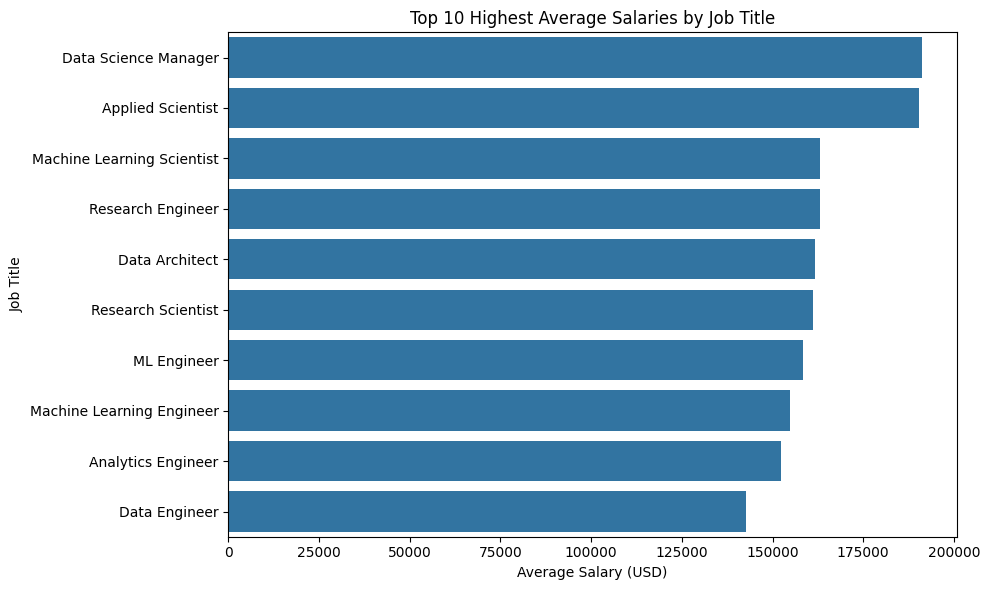

In [13]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_salary_jobs["mean"],
    y=top_salary_jobs.index
)

plt.title("Top 10 Highest Average Salaries by Job Title")
plt.xlabel("Average Salary (USD)")
plt.ylabel("Job Title")

plt.tight_layout()
plt.show()

## Important Finding

For occupations with at least 20 observations, the role with the highest average salary was Data Science Manager, at approximately \$191,000, where Applied Scientist came in second at around \$190,000.  

There are a handful of machine learning and research-related positions that also had average salaries ranging above \$150,000. These findings suggest that various specialized and senior technical roles were associated with higher average salaries within the selected dataset.

Occupations that contained less than 20 observations were removed from this comparison to minimize the influence of much smaller sample sizes.

In [14]:
experience_salary = (
    df.groupby("experience_level_label")["salary_in_usd"]
    .agg(["mean", "median", "count"])
    .sort_values("mean")
)

experience_salary

,mean,median,count
experience_level_label,,,
Entry-Level,78546.284375,70000.0,320
Middle-Level,104525.939130,100000.0,805
Senior-Level,153051.071542,146000.0,2516
Executive-Level,194930.929825,196000.0,114


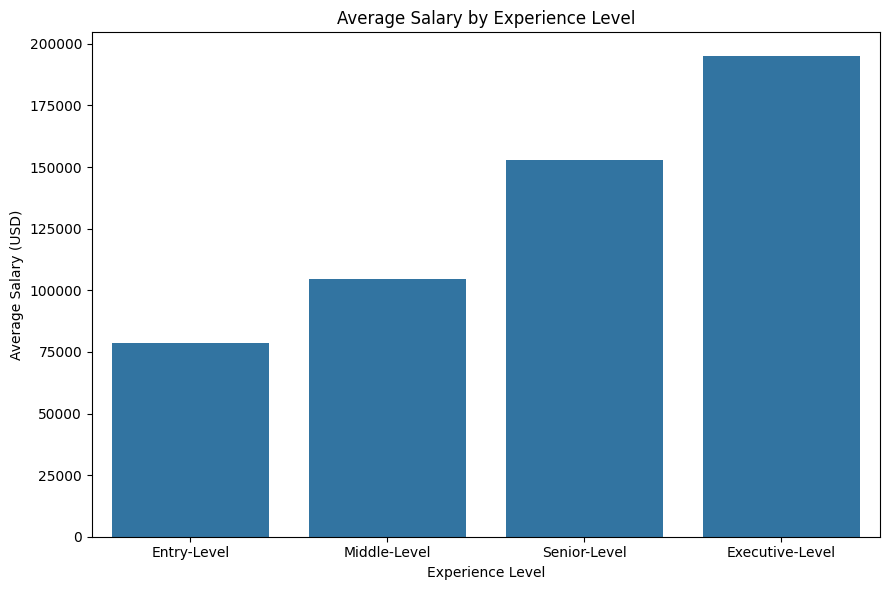

In [15]:
plt.figure(figsize=(9, 6))

sns.barplot(
    x=experience_salary.index,
    y=experience_salary["mean"]
)

plt.title("Average Salary by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Average Salary (USD)")

plt.tight_layout()
plt.show()

## Notable Observation

As experience level increased, average salary would also see an increase. For entry-level roles, the average salary was roughly \$78,000, compared to middle-level roles where the average salary sat at approximately \$104,000 and where the highest average salaries belonged to executive-level roles, at around \$194,000.

Median salaries demonstrated a similar trend, growing from \$70,000 for entry-level occupations to about \$196,000 for executive-level roles. Based on this dataset, both measures suggest a clear association between higher experience levels and higher salaries.

In [16]:
remote_salary = (
    df.groupby("remote_work_label")["salary_in_usd"]
    .agg(["mean", "median", "count"])
    .sort_values("mean")
)

remote_salary

,mean,median,count
remote_work_label,,,
Hybrid,78400.687831,63312.0,189
Fully Remote,136481.452830,135000.0,1643
On-site,144316.202288,139600.0,1923


Text(0, 0.5, 'Average Salary (USD)')

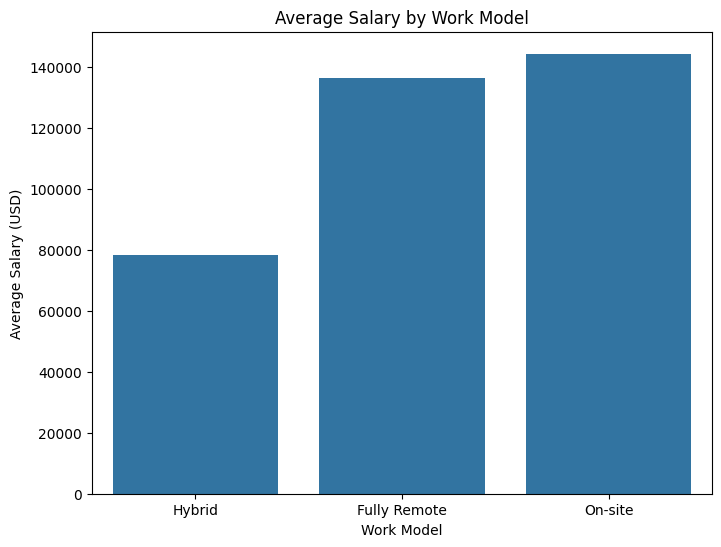

In [17]:
plt.figure(figsize=(8, 6))

sns.barplot(
    x = remote_salary.index,
    y = remote_salary["mean"]

)

plt.title("Average Salary by Work Model")
plt.xlabel("Work Model")
plt.ylabel("Average Salary (USD)")



## Notable Observation

The work model with the highest average salary was on-site roles at roughly \$144,000, where remote occupations would come in at second with an average salary of about \$136,000. The work model that produced the lowest average salary were the hybrid roles, at around \$78,000 annually.

Median salaries showed a similar trend, with on-site and remote roles having median salaries of roughly \$139,000 and \$135,000, whereas hybrid roles typically sat at around \$63,000.

These findings outline salary differences across work models within this dataset. Yet, they do not conclude that the work model itself leads to differences in salary, considering elements such as levels of experience, position, job location and year may also vary across these categories.

In [18]:
yearly_salary = (
    df.groupby("work_year")["salary_in_usd"]
    .agg(["mean", "median", "count"])
)

yearly_salary

,mean,median,count
work_year,,,
2020,92302.631579,73065.0,76
2021,94087.208696,80000.0,230
2022,133338.620793,131300.0,1664
2023,149045.541176,143860.0,1785


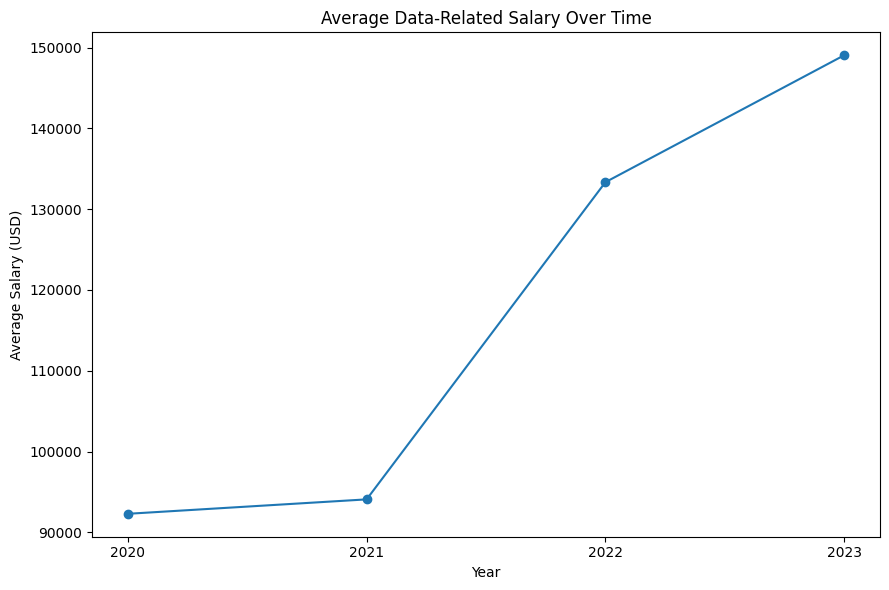

In [19]:
plt.figure(figsize=(9, 6))

plt.plot(
    yearly_salary.index,
    yearly_salary["mean"],
    marker = "o"
)

plt.title("Average Data-Related Salary Over Time")
plt.xlabel("Year")
plt.ylabel("Average Salary (USD)")
plt.xticks(yearly_salary.index)

plt.tight_layout()
plt.show()

## Notable Observation

Average salaries would see an increase from 2020 to 2023 as represented in the dataset, where it would increase from around $92,0000 in 2020 to approximately \$149,000 in 2023. The largest increases took place after 2021, where the average salary would climb to around \$133,000 in 2022 and would go on to only see an increasing moving forward in 2023.

Median salaries showed a similar pattern, rising from roughly \$73,000 in 2020 to around $143,000 in 2023. This implies that the boost in average salary was associated with higher salaries across more dispersed observations.

Despite this, the number of observations differs significantly year-to-year. To strengthen, the dataset consists of only 76 observations from 2020 and about 230 observations from 2021, compared with 1,664 from 2022 and roughly 1,785 from the data in 2023. With this in mind, these findings outline salary trends within this selected dataset and should not be evaluated as evidence that time itself led to an increase in overall salaries.

## 6. Important Findings and Conclusion

This analysis analyzed salary and employment trends across data-related roles utilizing information on job titles, levels of experience, work models and time periods.

## Important Findings

- The most commonly represented job was the Data Engineer position, where this consisted of 1,040 observations, where this would be followed by Data Scientist and Data Analyst.

- For the occuptions with at least 20 observations, the roles that earned the highest salaries were the Data Science Manager and Applied Scientist positions, ranging from \$190,000 to \$191,000 for average annual salaries.

- Higher experience levels were linked to higher average salaries in the selected dataset. The average salary varied from around \$78k for entry-level jobs and up to \$194,000 for executive level jobs.  

- The positions that earned the highest average salaries were on-site roles, where these salaries typically sat at around \$144,000, whereas remote occuaptions would come in next where these workers working remotely made slighly less at aroun \$136,000. In this dataset, hybrid roles typically had much lower average salary compared to the other work model.

- Average salaries increased across the years presented, where previously in 2020, the average salaries were around \$92,000. Fast foward to 2023, and the average salaries would increase significantly reaching \$149,000. Yet, the number of observations was significantly lower during the time periods of 2020 and 2021.

## Conclusion

In summary, the analysis demonstrates visible differences in salaries across job title, levels of experience, work models, and time period. Experience level showcased a noticeable relationship with salary whereas specialized managerial and technical occupations were recognized as the higher-paying roles depicted in the dataset.

These results illustrate trends within the dataset and should not be viewed as reflective of the entire data-related job market. Components such as employer location, job title, company characteristics, and unequal sample sizes may affect the observed findings.

